In [72]:
# ── 기본 데이터 처리 ──
import numpy as np
import pandas as pd

# ── 시각화 ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── 전처리 · 피처 ──
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# ── 모델 ──
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

# ── 평가 ──
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              mean_squared_error, mean_absolute_error, r2_score)

# ── 튜닝 ──
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# ── 모델 저장 ──
import joblib

In [73]:
SEED = 42
np.random.seed(SEED)

# sklearn 모델에 전달
# model = RandomForestClassifier(random_state=SEED)
# train_test_split(..., random_state=SEED)

In [74]:
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

In [75]:
import platform
# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [76]:
df = pd.read_csv('Courses.csv')

In [77]:
df

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,2013-11-17,NaN,9.0000,NaN,NaN,0,NaN,1.0000
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaN,NaN,9.0000,NaN,1.0000,0,NaN,1.0000
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,2013-11-17,NaN,16.0000,NaN,NaN,0,NaN,1.0000
3,3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaN,NaN,16.0000,NaN,NaN,0,NaN,1.0000
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaN,NaN,16.0000,NaN,NaN,0,NaN,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641133,641133,MITx/6.00x/2013_Spring,MHxPC130184108,1,1,0,0,Canada,Bachelor's,1991.0000,m,NaN,2013-09-07,2013-09-07,97.0000,1.0000,4.0000,2.0000,0,NaN,NaN
641134,641134,MITx/6.00x/2013_Spring,MHxPC130359782,1,0,0,0,Other Europe,Bachelor's,1991.0000,f,NaN,2013-09-07,2013-09-07,1.0000,1.0000,NaN,NaN,0,NaN,NaN
641135,641135,MITx/6.002x/2013_Spring,MHxPC130098513,1,0,0,0,United States,Doctorate,1979.0000,m,NaN,2013-09-07,2013-09-07,1.0000,1.0000,NaN,NaN,0,NaN,NaN
641136,641136,MITx/6.00x/2013_Spring,MHxPC130098513,1,1,0,0,United States,Doctorate,1979.0000,m,NaN,2013-09-07,2013-09-07,74.0000,1.0000,14.0000,1.0000,0,NaN,NaN


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641138 entries, 0 to 641137
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   index              641138 non-null  int64  
 1   course_id          641138 non-null  object 
 2   userid_DI          641138 non-null  object 
 3   registered         641138 non-null  int64  
 4   viewed             641138 non-null  int64  
 5   explored           641138 non-null  int64  
 6   certified          641138 non-null  int64  
 7   final_cc_cname_DI  641138 non-null  object 
 8   LoE_DI             535130 non-null  object 
 9   YoB                544533 non-null  float64
 10  gender             554332 non-null  object 
 11  grade              592766 non-null  object 
 12  start_time_DI      641138 non-null  object 
 13  last_event_DI      462184 non-null  object 
 14  nevents            441987 non-null  float64
 15  ndays_act          478395 non-null  float64
 16  np

In [79]:
df.describe()

,index,registered,viewed,explored,certified,YoB,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
count,641138.0000,641138.0000,641138.0000,641138.0000,641138.0000,544533.0000,441987.0000,478395.0000,183608.0000,382385.0000,641138.0000,0.0000,100161.0000
mean,320568.5000,1.0000,0.6243,0.0619,0.0276,1985.2533,431.0080,5.7103,114.8442,3.6344,0.0190,NaN,1.0000
std,185080.7428,0.0000,0.4843,0.2410,0.1638,8.8918,1516.1161,11.8665,426.9968,4.4910,0.2295,NaN,0.0000
min,0.0000,1.0000,0.0000,0.0000,0.0000,1931.0000,1.0000,1.0000,1.0000,1.0000,0.0000,NaN,1.0000
25%,160284.2500,1.0000,0.0000,0.0000,0.0000,1982.0000,3.0000,1.0000,5.0000,1.0000,0.0000,NaN,1.0000
50%,320568.5000,1.0000,1.0000,0.0000,0.0000,1988.0000,24.0000,2.0000,18.0000,2.0000,0.0000,NaN,1.0000
75%,480852.7500,1.0000,1.0000,0.0000,0.0000,1991.0000,158.0000,4.0000,73.0000,4.0000,0.0000,NaN,1.0000
max,641137.0000,1.0000,1.0000,1.0000,1.0000,2013.0000,197757.0000,205.0000,98517.0000,48.0000,20.0000,NaN,1.0000


In [80]:
df.isna().sum()

index                     0
course_id                 0
userid_DI                 0
registered                0
viewed                    0
explored                  0
certified                 0
final_cc_cname_DI         0
LoE_DI               106008
YoB                   96605
gender                86806
grade                 48372
start_time_DI             0
last_event_DI        178954
nevents              199151
ndays_act            162743
nplay_video          457530
nchapters            258753
nforum_posts              0
roles                641138
incomplete_flag      540977
dtype: int64

### course id 

In [ ]:
display(df['course_id'].nunique())
display(df['course_id'].unique())

16

array(['HarvardX/CB22x/2013_Spring', 'HarvardX/CS50x/2012',
       'HarvardX/ER22x/2013_Spring', 'HarvardX/PH207x/2012_Fall',
       'HarvardX/PH278x/2013_Spring', 'MITx/6.002x/2012_Fall',
       'MITx/6.002x/2013_Spring', 'MITx/14.73x/2013_Spring',
       'MITx/2.01x/2013_Spring', 'MITx/3.091x/2012_Fall',
       'MITx/3.091x/2013_Spring', 'MITx/6.00x/2012_Fall',
       'MITx/6.00x/2013_Spring', 'MITx/7.00x/2013_Spring',
       'MITx/8.02x/2013_Spring', 'MITx/8.MReV/2013_Summer'], dtype=object)

In [ ]:
display(df['course_id'].value_counts())
print(df['course_id'].value_counts(normalize=True))

course_id
HarvardX/CS50x/2012            169616
MITx/6.00x/2012_Fall            66705
MITx/6.00x/2013_Spring          57712
HarvardX/ER22x/2013_Spring      56952
HarvardX/PH207x/2012_Fall       41591
MITx/6.002x/2012_Fall           40793
HarvardX/PH278x/2013_Spring     39530
MITx/8.02x/2013_Spring          31044
HarvardX/CB22x/2013_Spring      30000
MITx/14.73x/2013_Spring         27861
MITx/6.002x/2013_Spring         22214
MITx/7.00x/2013_Spring          20988
MITx/3.091x/2012_Fall           14215
MITx/8.MReV/2013_Summer          9447
MITx/3.091x/2013_Spring          6108
MITx/2.01x/2013_Spring           5664
Name: count, dtype: int64

course_id
HarvardX/CS50x/2012           0.2648
MITx/6.00x/2012_Fall          0.1042
MITx/6.00x/2013_Spring        0.0901
HarvardX/ER22x/2013_Spring    0.0889
HarvardX/PH207x/2012_Fall     0.0649
MITx/6.002x/2012_Fall         0.0637
HarvardX/PH278x/2013_Spring   0.0617
MITx/8.02x/2013_Spring        0.0485
HarvardX/CB22x/2013_Spring    0.0468
MITx/14.73x/2013_Spring       0.0435
MITx/6.002x/2013_Spring       0.0347
MITx/7.00x/2013_Spring        0.0328
MITx/3.091x/2012_Fall         0.0222
MITx/8.MReV/2013_Summer       0.0148
MITx/3.091x/2013_Spring       0.0095
MITx/2.01x/2013_Spring        0.0088
Name: proportion, dtype: float64

In [81]:
# ── 기본 구조 확인 ────────────────────────────
print(f"shape: {df.shape}")
print(f"\ndtypes:\n{df.dtypes}")
print(f"\n메모리 사용량:")
df.info(memory_usage="deep")

# ── 빠른 품질 스냅샷 ──────────────────────────
def quality_snapshot(df: pd.DataFrame) -> pd.DataFrame:
    """컬럼별 결측률·고유값·최빈값·타입을 한눈에 보여준다."""
    report = pd.DataFrame({
        "dtype":      df.dtypes,
        "non_null":   df.count(),
        "null_pct":   (df.isnull().mean() * 100).round(1),
        "nunique":    df.nunique(),
        "top_value":  df.apply(lambda c: c.mode().iloc[0] if not c.mode().empty else np.nan),
        "sample":     df.iloc[0],
    })
    return report

quality_snapshot(df)

shape: (641138, 21)

dtypes:
index                  int64
course_id             object
userid_DI             object
registered             int64
viewed                 int64
explored               int64
certified              int64
final_cc_cname_DI     object
LoE_DI                object
YoB                  float64
gender                object
grade                 object
start_time_DI         object
last_event_DI         object
nevents              float64
ndays_act            float64
nplay_video          float64
nchapters            float64
nforum_posts           int64
roles                float64
incomplete_flag      float64
dtype: object

메모리 사용량:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641138 entries, 0 to 641137
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   index              641138 non-null  int64  
 1   course_id          641138 non-null  object 
 2   userid_DI          641138 

,dtype,non_null,null_pct,nunique,top_value,sample
index,int64,641138,0.0000,641138,0,0
course_id,object,641138,0.0000,16,HarvardX/CS50x/2012,HarvardX/CB22x/2013_Spring
userid_DI,object,641138,0.0000,476532,MHxPC130027283,MHxPC130442623
registered,int64,641138,0.0000,1,1,1
viewed,int64,641138,0.0000,2,1,0
explored,int64,641138,0.0000,2,0,0
certified,int64,641138,0.0000,2,0,0
final_cc_cname_DI,object,641138,0.0000,34,United States,United States
LoE_DI,object,535130,16.5000,5,Bachelor's,NaN
YoB,float64,544533,15.1000,78,1990.0000,NaN


In [82]:
# 기존: drop_cols = ['roles', 'incomplete_flag', registered]
drop_cols = ['roles', 'registered']
df.drop(columns=drop_cols, inplace=True, errors='ignore')
df

,index,course_id,userid_DI,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,2013-11-17,NaN,9.0000,NaN,NaN,0,1.0000
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaN,NaN,9.0000,NaN,1.0000,0,1.0000
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,2013-11-17,NaN,16.0000,NaN,NaN,0,1.0000
3,3,HarvardX/CS50x/2012,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaN,NaN,16.0000,NaN,NaN,0,1.0000
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaN,NaN,16.0000,NaN,NaN,0,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641133,641133,MITx/6.00x/2013_Spring,MHxPC130184108,1,0,0,Canada,Bachelor's,1991.0000,m,NaN,2013-09-07,2013-09-07,97.0000,1.0000,4.0000,2.0000,0,NaN
641134,641134,MITx/6.00x/2013_Spring,MHxPC130359782,0,0,0,Other Europe,Bachelor's,1991.0000,f,NaN,2013-09-07,2013-09-07,1.0000,1.0000,NaN,NaN,0,NaN
641135,641135,MITx/6.002x/2013_Spring,MHxPC130098513,0,0,0,United States,Doctorate,1979.0000,m,NaN,2013-09-07,2013-09-07,1.0000,1.0000,NaN,NaN,0,NaN
641136,641136,MITx/6.00x/2013_Spring,MHxPC130098513,1,0,0,United States,Doctorate,1979.0000,m,NaN,2013-09-07,2013-09-07,74.0000,1.0000,14.0000,1.0000,0,NaN


In [83]:
# 1. 제거할 모순 데이터의 3가지 조건 정의
invalid_condition = (
    ((df['viewed'] == 0) & (df['explored'] == 1)) |   # 모순 1: 방문 안 했는데 탐색함
    ((df['explored'] == 0) & (df['certified'] == 1)) | # 모순 2: 탐색 안 했는데 수료증 받음
    ((df['viewed'] == 0) & (df['certified'] == 1))     # 모순 3: 방문 안 했는데 수료증 받음
)

# 2. 제거되기 전 데이터 수 확인
print(f"제거 전 원본 데이터 수: {len(df):,}건")

# 3. 모순이 되는 행(invalid_condition이 True인 것)들의 개수 확인
invalid_count = invalid_condition.sum()
print(f"시스템 누락/모순 데이터 수: {invalid_count:,}건")

# 4. 정제된 온전한 데이터프레임으로 갱신
# 물결표(~) 기호는 조건의 반대(Not)를 의미합니다. 즉, 모순이 "아닌" 깨끗한 데이터만 남깁니다.
df = df[~invalid_condition]

print(f"✅ 에러 데이터 제거 후 맑아진 데이터 수: {len(df):,}건")


제거 전 원본 데이터 수: 641,138건
시스템 누락/모순 데이터 수: 698건
✅ 에러 데이터 제거 후 맑아진 데이터 수: 640,440건


In [84]:
nplay_null = df[df['nplay_video'].isna()]
nplay_null


,index,course_id,userid_DI,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,2013-11-17,NaN,9.0000,NaN,NaN,0,1.0000
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaN,NaN,9.0000,NaN,1.0000,0,1.0000
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,2013-11-17,NaN,16.0000,NaN,NaN,0,1.0000
3,3,HarvardX/CS50x/2012,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaN,NaN,16.0000,NaN,NaN,0,1.0000
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaN,NaN,16.0000,NaN,NaN,0,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641131,641131,MITx/8.02x/2013_Spring,MHxPC130226305,0,0,0,Unknown/Other,Bachelor's,1988.0000,m,NaN,2013-09-07,2013-09-07,11.0000,1.0000,NaN,2.0000,0,NaN
641132,641132,MITx/6.002x/2013_Spring,MHxPC130030805,1,0,0,Pakistan,Master's,1989.0000,m,NaN,2013-09-07,2013-09-07,29.0000,1.0000,NaN,1.0000,0,NaN
641134,641134,MITx/6.00x/2013_Spring,MHxPC130359782,0,0,0,Other Europe,Bachelor's,1991.0000,f,NaN,2013-09-07,2013-09-07,1.0000,1.0000,NaN,NaN,0,NaN
641135,641135,MITx/6.002x/2013_Spring,MHxPC130098513,0,0,0,United States,Doctorate,1979.0000,m,NaN,2013-09-07,2013-09-07,1.0000,1.0000,NaN,NaN,0,NaN


In [85]:
nplay_null.info()

<class 'pandas.core.frame.DataFrame'>
Index: 456999 entries, 0 to 641137
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   index              456999 non-null  int64  
 1   course_id          456999 non-null  object 
 2   userid_DI          456999 non-null  object 
 3   viewed             456999 non-null  int64  
 4   explored           456999 non-null  int64  
 5   certified          456999 non-null  int64  
 6   final_cc_cname_DI  456999 non-null  object 
 7   LoE_DI             386880 non-null  object 
 8   YoB                394561 non-null  float64
 9   gender             401606 non-null  object 
 10  grade              423857 non-null  object 
 11  start_time_DI      456999 non-null  object 
 12  last_event_DI      278048 non-null  object 
 13  nevents            259847 non-null  float64
 14  ndays_act          294258 non-null  float64
 15  nplay_video        0 non-null       float64
 16  nchapte

In [86]:
nplay_null.describe()

,index,viewed,explored,certified,YoB,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag
count,456999.0000,456999.0000,456999.0000,456999.0000,394561.0000,259847.0000,294258.0000,0.0000,199377.0000,456999.0000,98162.0000
mean,276290.2989,0.4732,0.0348,0.0084,1985.0736,68.3472,3.0916,NaN,3.1514,0.0072,1.0000
std,179355.0058,0.4993,0.1832,0.0915,9.1271,302.8527,6.4936,NaN,4.5243,0.1204,0.0000
min,0.0000,0.0000,0.0000,0.0000,1931.0000,1.0000,1.0000,NaN,1.0000,0.0000,1.0000
25%,124933.5000,0.0000,0.0000,0.0000,1982.0000,2.0000,1.0000,NaN,1.0000,0.0000,1.0000
50%,253658.0000,0.0000,0.0000,0.0000,1987.0000,5.0000,1.0000,NaN,2.0000,0.0000,1.0000
75%,412627.5000,1.0000,0.0000,0.0000,1991.0000,25.0000,2.0000,NaN,3.0000,0.0000,1.0000
max,641137.0000,1.0000,1.0000,1.0000,2013.0000,31943.0000,176.0000,NaN,48.0000,7.0000,1.0000


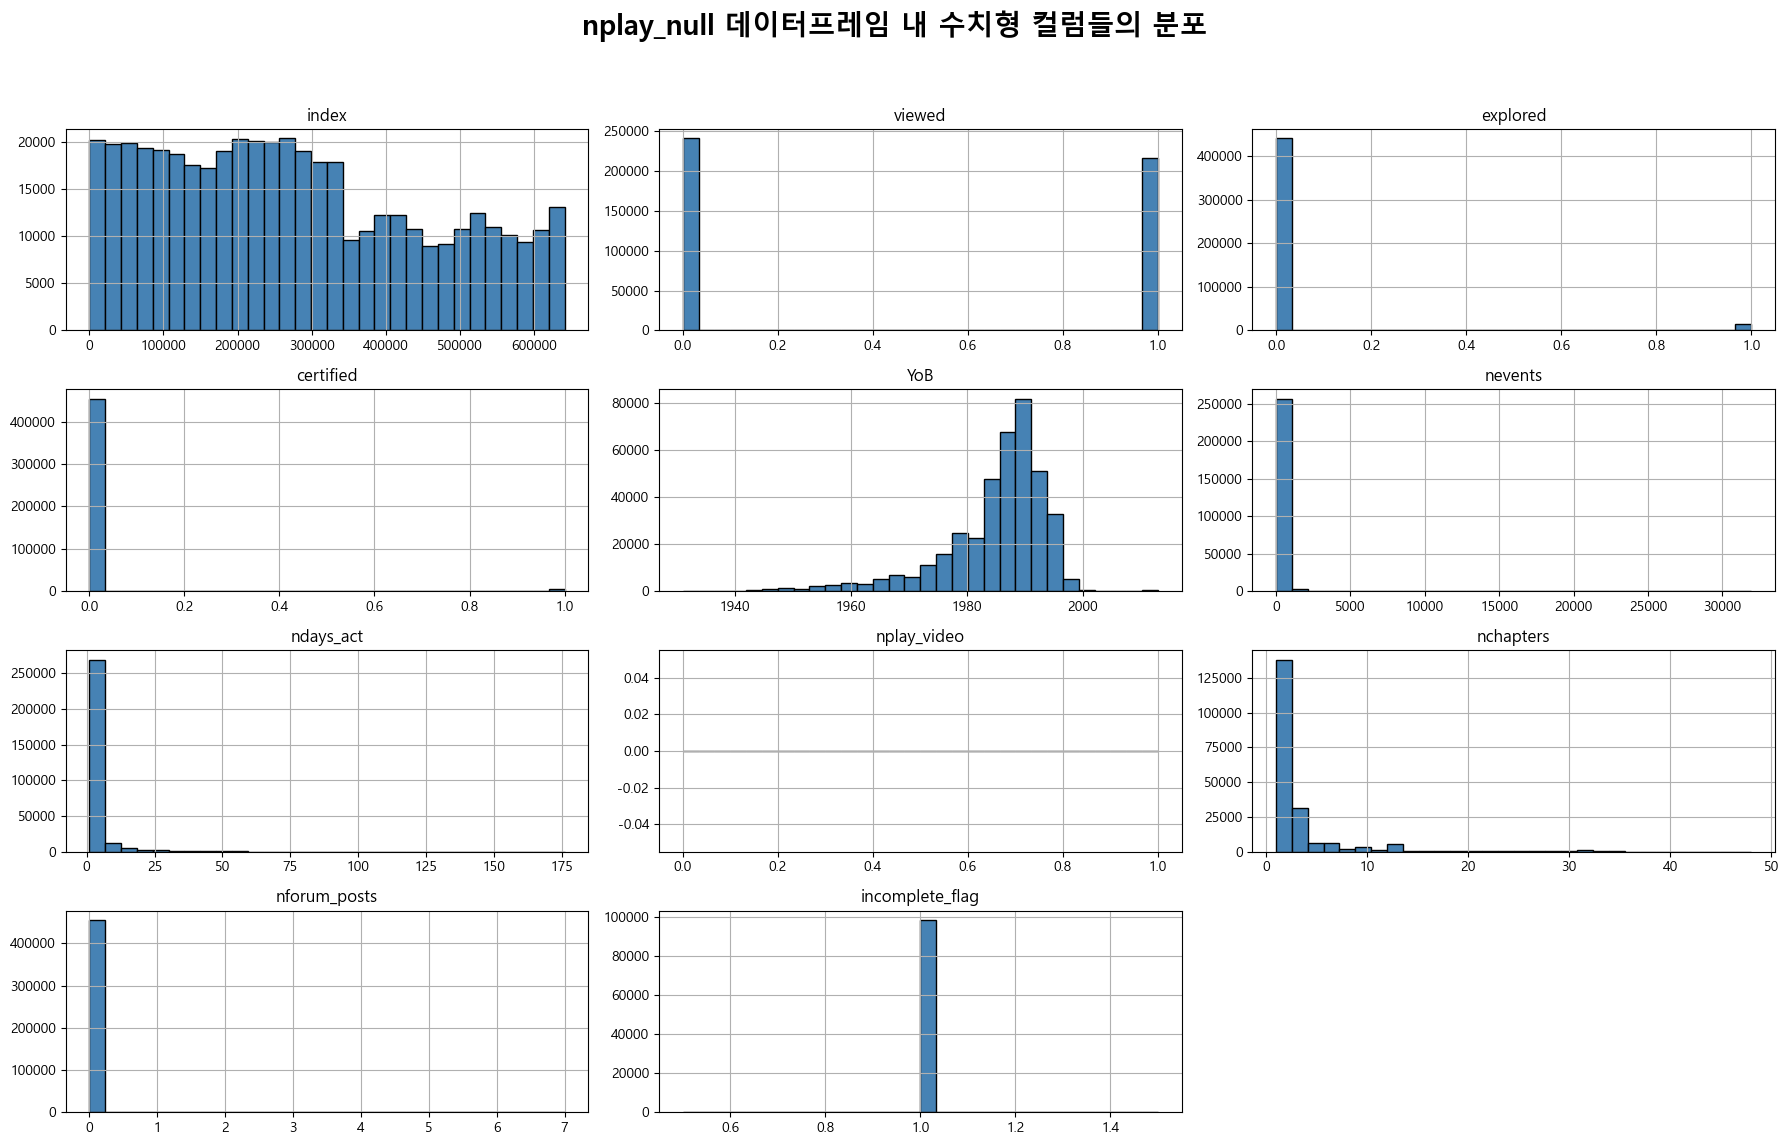

In [87]:
# 수치형 데이터에 대해 히스토그램을 한 번에 여러 개 그리기
# bins: 막대의 개수 (숫자가 클수록 더 잘게 쪼개서 보여줌)
# figsize: 바탕이 되는 전체 그림 사이즈 설정 (가로, 세로)
nplay_null.hist(bins=30, figsize=(18, 12), color='steelblue', edgecolor='black')

# 전체 그래프의 대제목 추가
plt.suptitle('nplay_null 데이터프레임 내 수치형 컬럼들의 분포', fontsize=20, fontweight='bold')

# 그래프들 간의 간격이 겹치지 않도록 자동 조정
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()


✅ 영상 시청 집단(not null) 수: 183,441건
❌ 영상 미시청 집단(null) 수:  456,999건



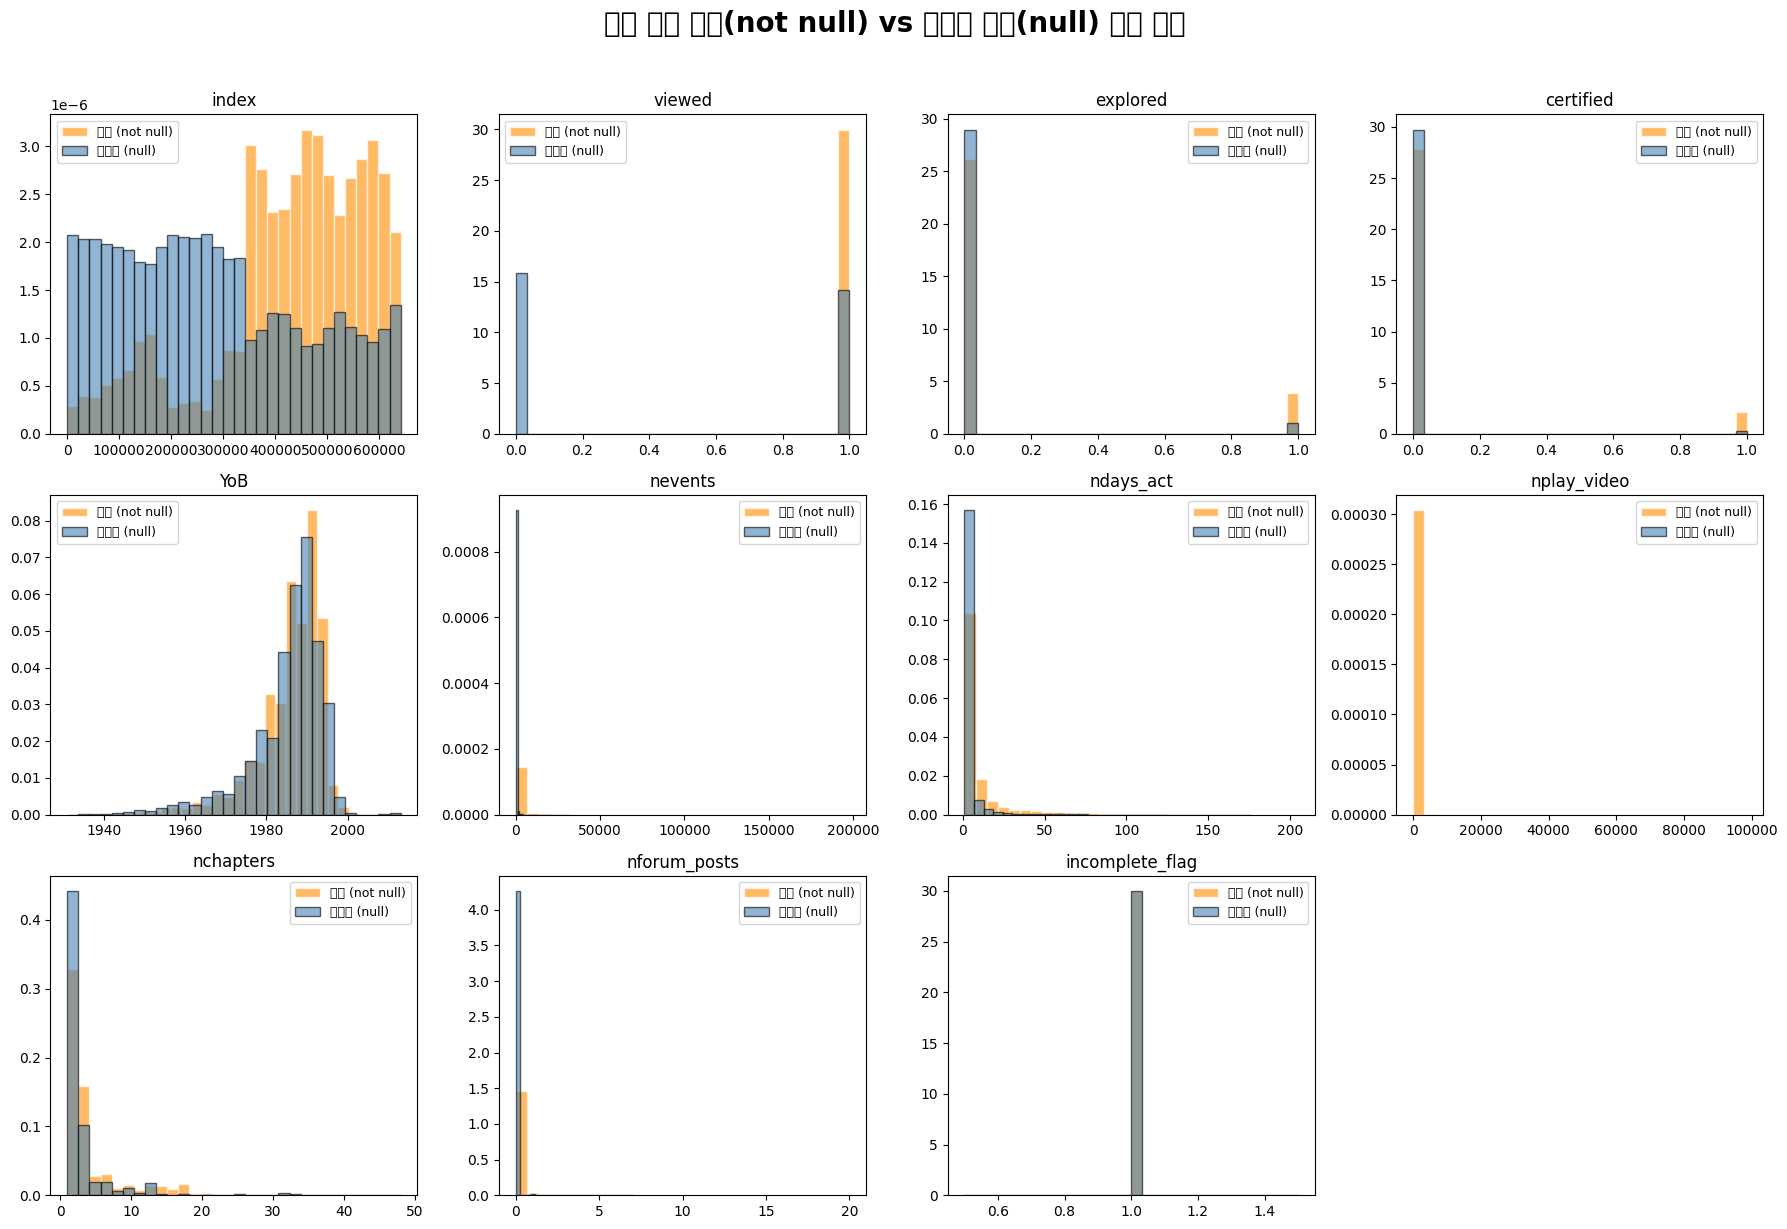

In [88]:
# 1. nplay_video가 Null이 아닌(영상을 1번이라도 재생한) 새로운 데이터프레임 생성
nplay_not_null = df[df['nplay_video'].notnull()]

print(f"✅ 영상 시청 집단(not null) 수: {len(nplay_not_null):,}건")
print(f"❌ 영상 미시청 집단(null) 수:  {len(nplay_null):,}건\n")

# 2. 두 집단의 수치형 컬럼 분포 비교 시각화
plt.style.use('default')

# 수치형 컬럼 시각화 대상을 지정
num_cols = df.select_dtypes(include=['number', 'float64', 'int64']).columns

n_cols = 4 
n_rows = (len(num_cols) - 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    
    # density=True(정규화)를 적용해야 두 집단의 모수가 달라도 분포 곡선의 '모양'을 정확히 비교할 수 있습니다.
    
    # [시청 집단] (nplay_not_null) - 반투명한 주황색
    ax.hist(nplay_not_null[col].dropna(), bins=30, alpha=0.6, color='darkorange', 
            label='시청 (not null)', density=True, edgecolor='white')
    
    # [미시청 집단] (nplay_null) - 반투명한 파란색
    ax.hist(nplay_null[col].dropna(), bins=30, alpha=0.6, color='steelblue', 
            label='미시청 (null)', density=True, edgecolor='black')
    
    ax.set_title(col, fontsize=12)
    ax.legend(fontsize=9)

# 남는 그림 공간 삭제
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('영상 시청 집단(not null) vs 미시청 집단(null) 분포 비교', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [89]:
# 행(row) 기준으로 하나라도 결측치(NaN/Null)가 있는지 확인 후 그 개수 합산
missing_rows_count = df.isnull().any(axis=1).sum()

print(f"하나라도 결측치가 있는 행의 총 개수: {missing_rows_count}개")


하나라도 결측치가 있는 행의 총 개수: 640440개


In [90]:
# 전체 행 기준 중복값 총 개수 확인
duplicate_count = df.duplicated().sum()
print(f"전체 중복 데이터 개수: {duplicate_count}건")


전체 중복 데이터 개수: 0건


In [91]:
# 특정 컬럼(유저 ID와 강좌 ID) 기준으로 중복 여부 확인
subset_dup_count = df.duplicated(subset=['userid_DI', 'course_id']).sum()

print(f"동일 유저가 동일 강의에 중복 등록된 것으로 추정되는 건수: {subset_dup_count}건")


동일 유저가 동일 강의에 중복 등록된 것으로 추정되는 건수: 0건


In [92]:
# 날짜 컬럼 형변환
df['start_time_DI'] = pd.to_datetime(df['start_time_DI'], errors='coerce')
df['last_event_DI'] = pd.to_datetime(df['last_event_DI'], errors='coerce')

# # 수강 기간 도출 (일 단위)
# df['duration_days'] = (df['last_event_DI'] - df['start_time_DI']).dt.days

# # 시작 시점 나이 도출
# if 'start_time_DI' in df.columns and 'YoB' in df.columns:
#     df['Age'] = df['start_time_DI'].dt.year - df['YoB']

# df

In [93]:
df.describe()

,index,viewed,explored,certified,YoB,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag
count,640440.0000,640440.0000,640440.0000,640440.0000,543924.0000,640440,461489,441292.0000,477699.0000,183441.0000,381687.0000,640440.0000,100158.0000
mean,320576.2744,0.6239,0.0620,0.0265,1985.2490,2013-01-02 13:44:21.854974976,2013-03-10 22:21:25.156526080,430.3095,5.7017,114.8831,3.6233,0.0190,1.0000
min,0.0000,0.0000,0.0000,0.0000,1931.0000,2012-07-23 00:00:00,2012-07-24 00:00:00,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000
25%,160189.7500,0.0000,0.0000,0.0000,1982.0000,2012-10-01 00:00:00,2012-12-25 00:00:00,3.0000,1.0000,5.0000,1.0000,0.0000,1.0000
50%,320655.5000,1.0000,0.0000,0.0000,1988.0000,2013-01-10 00:00:00,2013-03-17 00:00:00,24.0000,2.0000,18.0000,2.0000,0.0000,1.0000
75%,480909.2500,1.0000,0.0000,0.0000,1991.0000,2013-03-10 00:00:00,2013-05-29 00:00:00,156.0000,4.0000,73.0000,4.0000,0.0000,1.0000
max,641137.0000,1.0000,1.0000,1.0000,2013.0000,2013-09-08 00:00:00,2013-11-17 00:00:00,197757.0000,205.0000,98517.0000,48.0000,20.0000,1.0000
std,185120.2729,0.4844,0.2411,0.1607,8.8932,NaN,NaN,1516.6427,11.8656,427.1750,4.4835,0.2296,0.0000


In [94]:
df.isna().sum()

index                     0
course_id                 0
userid_DI                 0
viewed                    0
explored                  0
certified                 0
final_cc_cname_DI         0
LoE_DI               105920
YoB                   96516
gender                86726
grade                 48368
start_time_DI             0
last_event_DI        178951
nevents              199148
ndays_act            162741
nplay_video          456999
nchapters            258753
nforum_posts              0
incomplete_flag      540282
dtype: int64

In [95]:
last_event_null = df[df['last_event_DI'].isna()]
print(f"조건을 만족하는 총 행 개수: {len(last_event_null):,}건\n")
display(last_event_null)

조건을 만족하는 총 행 개수: 178,951건



,index,course_id,userid_DI,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaT,NaN,9.0000,NaN,1.0000,0,1.0000
3,3,HarvardX/CS50x/2012,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaT,NaN,16.0000,NaN,NaN,0,1.0000
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaT,NaN,16.0000,NaN,NaN,0,1.0000
6,6,HarvardX/PH278x/2013_Spring,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,NaT,NaN,16.0000,NaN,NaN,0,1.0000
9,9,HarvardX/CS50x/2012,MHxPC130088379,1,0,0,United States,NaN,NaN,NaN,0,2012-10-20,NaT,NaN,12.0000,NaN,3.0000,0,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641116,641116,MITx/14.73x/2013_Spring,MHxPC130555418,0,0,0,Unknown/Other,Bachelor's,1988.0000,m,NaN,2013-09-07,NaT,NaN,NaN,NaN,NaN,0,NaN
641118,641118,MITx/6.00x/2013_Spring,MHxPC130040184,0,0,0,United States,Secondary,1991.0000,m,NaN,2013-09-07,NaT,NaN,NaN,NaN,NaN,0,NaN
641121,641121,MITx/6.00x/2013_Spring,MHxPC130282999,0,0,0,Other Europe,Master's,1979.0000,m,NaN,2013-09-07,NaT,NaN,NaN,NaN,7.0000,0,1.0000
641129,641129,MITx/6.00x/2013_Spring,MHxPC130021638,0,0,0,Unknown/Other,Bachelor's,1988.0000,m,NaN,2013-09-07,NaT,NaN,NaN,NaN,NaN,0,NaN


In [96]:
# 두 가지 조건을 만족하는 필터(마스크) 생성
# 조건 1: last_event_DI가 Null(결측치)인가?
# 조건 2: nplay_video가 0인가?
condition = df['last_event_DI'].isnull() & (df['nplay_video'] == 0)

# 생성한 조건으로 데이터프레임 필터링
result_df = df[condition]

# 결과 출력
print(f"조건을 만족하는 총 행 개수: {len(result_df):,}건\n")
display(result_df)


조건을 만족하는 총 행 개수: 0건



,index,course_id,userid_DI,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,incomplete_flag


In [97]:
# 두 데이터프레임이 정확히 동일한지 판독 (True / False 반환)
is_identical = last_event_null.equals(result_df)

if is_identical:
    print("✅ 두 데이터프레임이 완벽하게 일치합니다.")
else:
    print("❌ 두 데이터프레임에 차이가 있습니다.")
    
    # 만약 다르다면, 최소한 행/열 개수라도 같은지 확인해 볼 수 있습니다.
    print(f"\n- last_event_null 크기: {last_event_null.shape}")
    print(f"- result_df 크기: {result_df.shape}")


❌ 두 데이터프레임에 차이가 있습니다.

- last_event_null 크기: (178951, 19)
- result_df 크기: (0, 19)


In [98]:
# nplay_video 결측치는 영상을 재생하지 않은 것(0)으로 대치
if 'nplay_video' in df.columns:
    df['nplay_video'] = df['nplay_video'].fillna(0)

In [99]:
drop_cols = ['incomplete_flag']
df.drop(columns=drop_cols, inplace=True, errors='ignore')
df

,index,course_id,userid_DI,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,2013-11-17,NaN,9.0000,0.0000,NaN,0
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaT,NaN,9.0000,0.0000,1.0000,0
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,2013-11-17,NaN,16.0000,0.0000,NaN,0
3,3,HarvardX/CS50x/2012,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaT,NaN,16.0000,0.0000,NaN,0
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaT,NaN,16.0000,0.0000,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641133,641133,MITx/6.00x/2013_Spring,MHxPC130184108,1,0,0,Canada,Bachelor's,1991.0000,m,NaN,2013-09-07,2013-09-07,97.0000,1.0000,4.0000,2.0000,0
641134,641134,MITx/6.00x/2013_Spring,MHxPC130359782,0,0,0,Other Europe,Bachelor's,1991.0000,f,NaN,2013-09-07,2013-09-07,1.0000,1.0000,0.0000,NaN,0
641135,641135,MITx/6.002x/2013_Spring,MHxPC130098513,0,0,0,United States,Doctorate,1979.0000,m,NaN,2013-09-07,2013-09-07,1.0000,1.0000,0.0000,NaN,0
641136,641136,MITx/6.00x/2013_Spring,MHxPC130098513,1,0,0,United States,Doctorate,1979.0000,m,NaN,2013-09-07,2013-09-07,74.0000,1.0000,14.0000,1.0000,0


In [100]:
# 행(row) 기준으로 하나라도 결측치(NaN/Null)가 있는지 확인 후 그 개수 합산
missing_rows_count = df.isnull().any(axis=1).sum()

print(f"하나라도 결측치가 있는 행의 총 개수: {missing_rows_count}개")


하나라도 결측치가 있는 행의 총 개수: 411542개


In [101]:
df.isna().sum()

index                     0
course_id                 0
userid_DI                 0
viewed                    0
explored                  0
certified                 0
final_cc_cname_DI         0
LoE_DI               105920
YoB                   96516
gender                86726
grade                 48368
start_time_DI             0
last_event_DI        178951
nevents              199148
ndays_act            162741
nplay_video               0
nchapters            258753
nforum_posts              0
dtype: int64

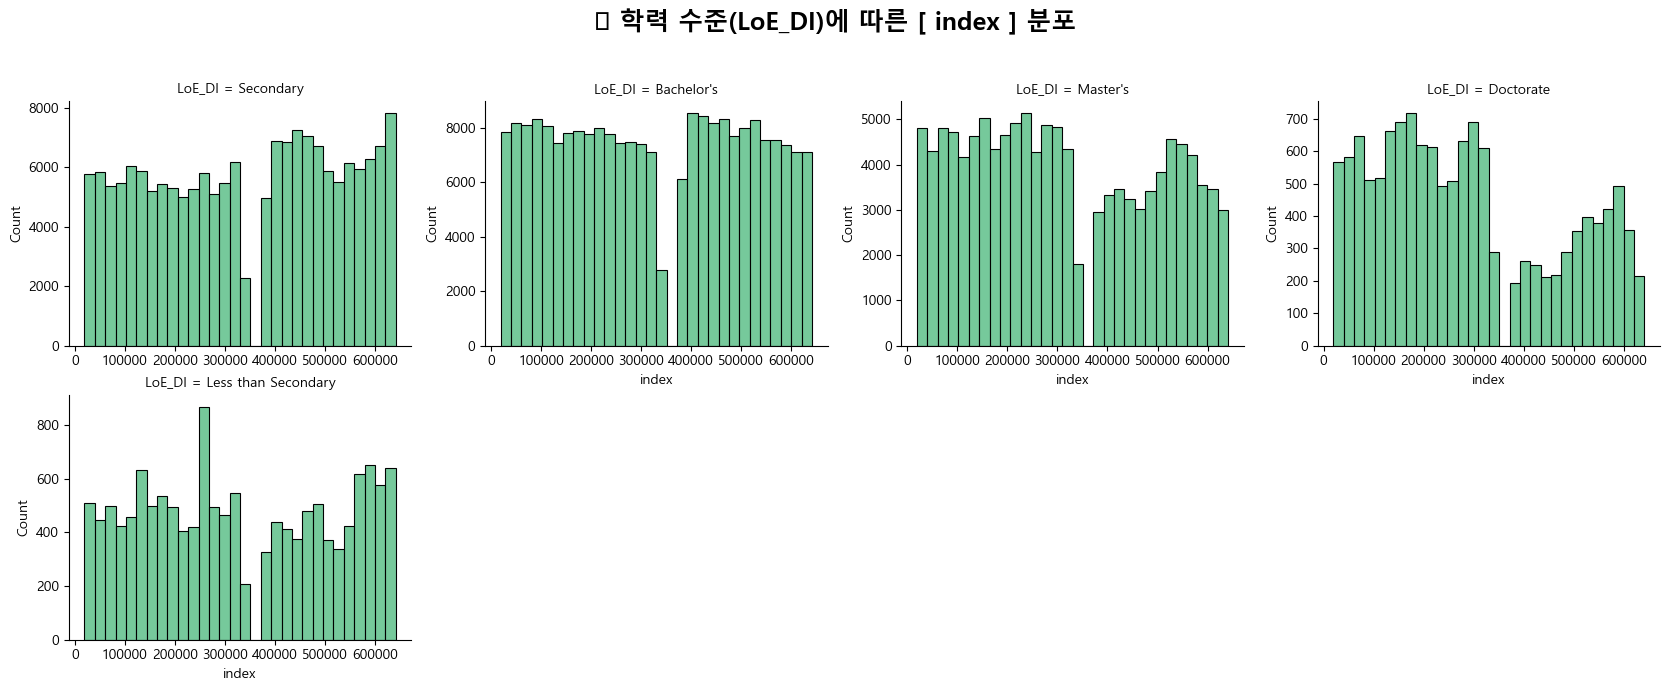

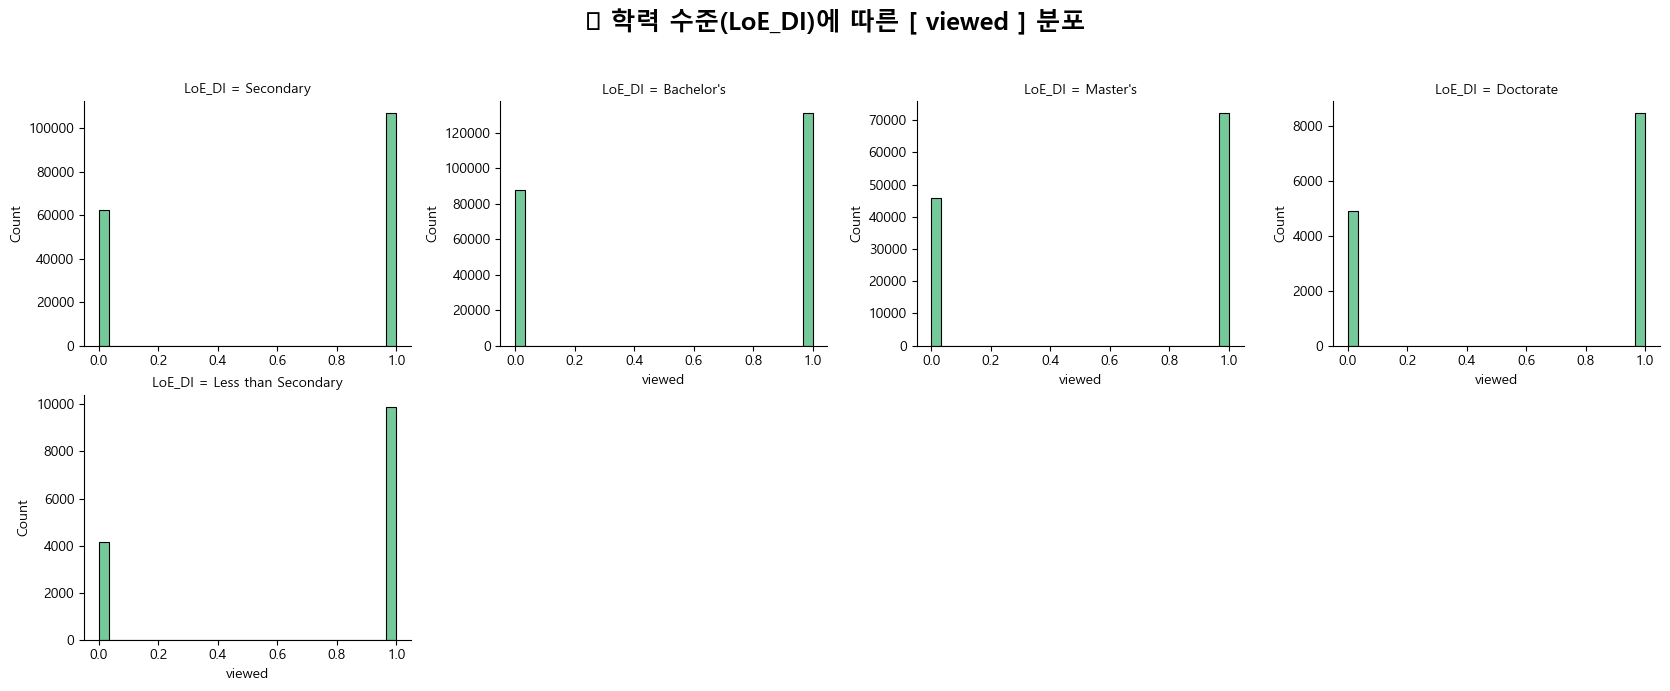

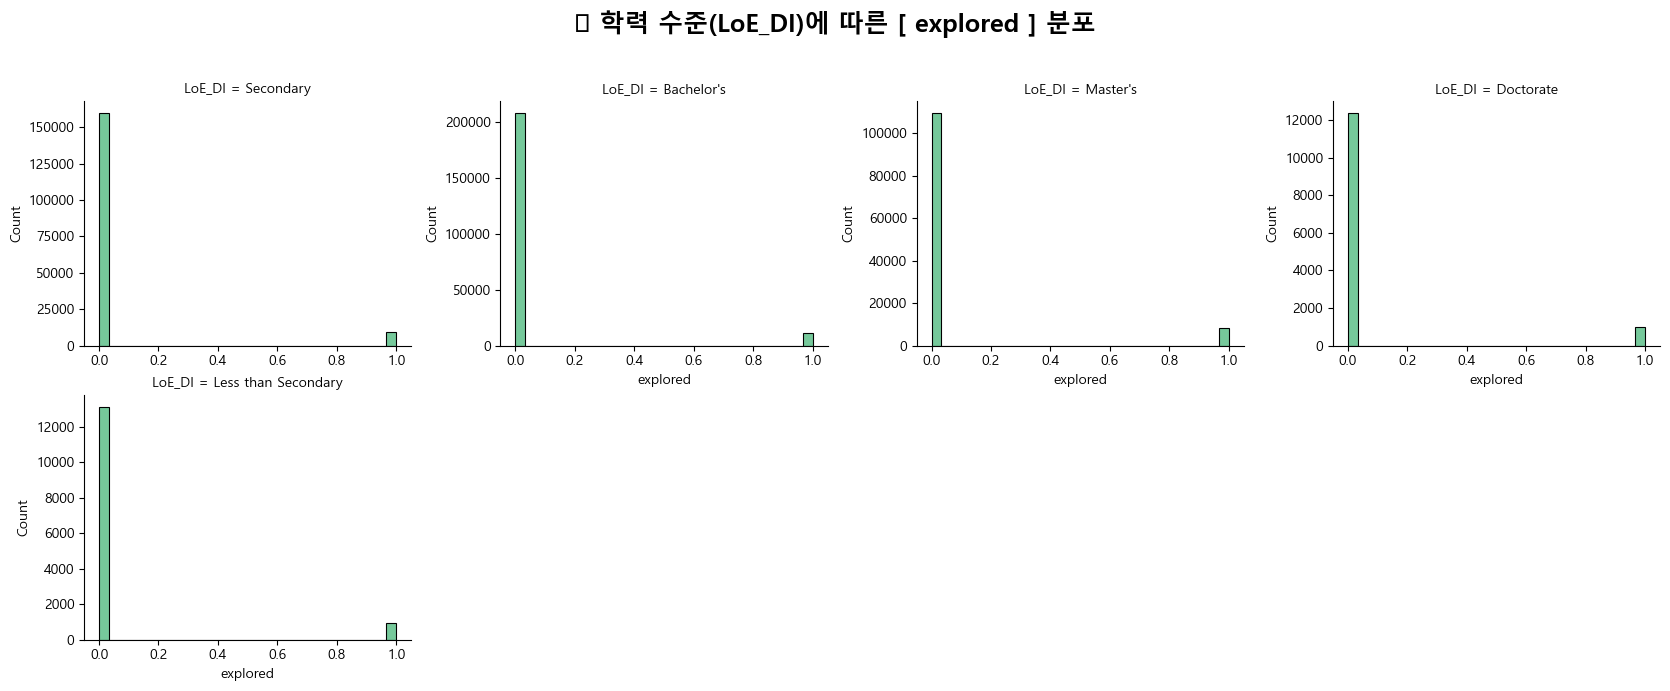

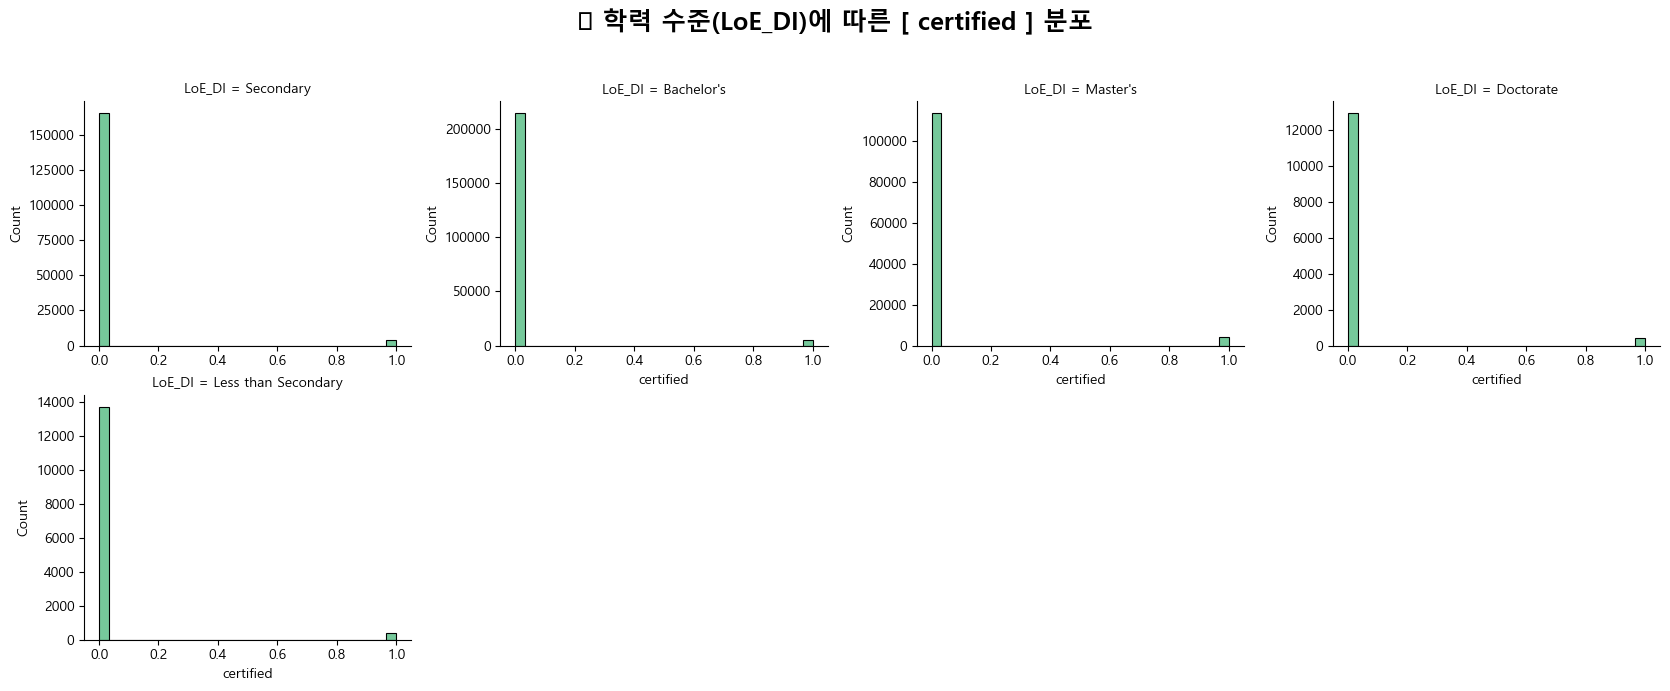

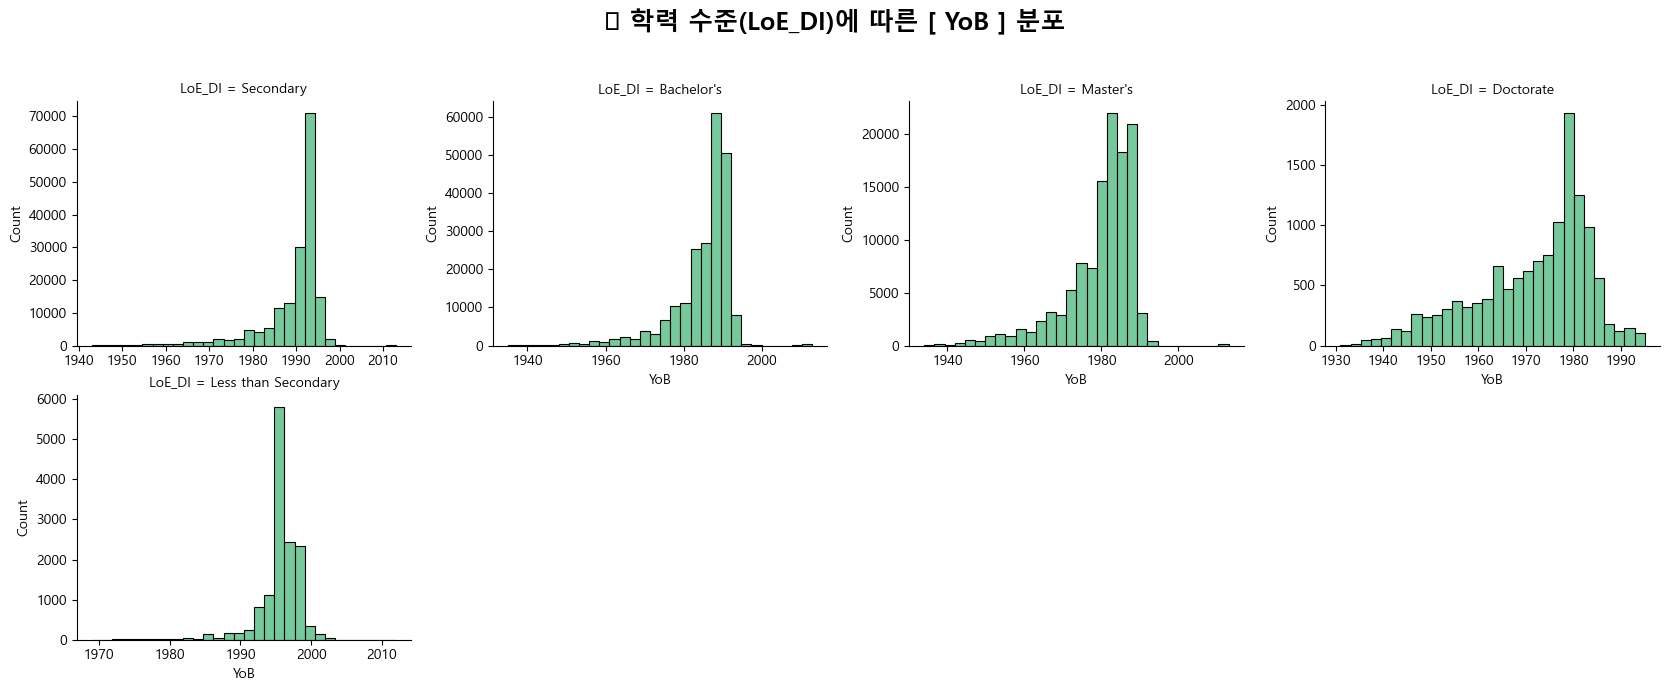

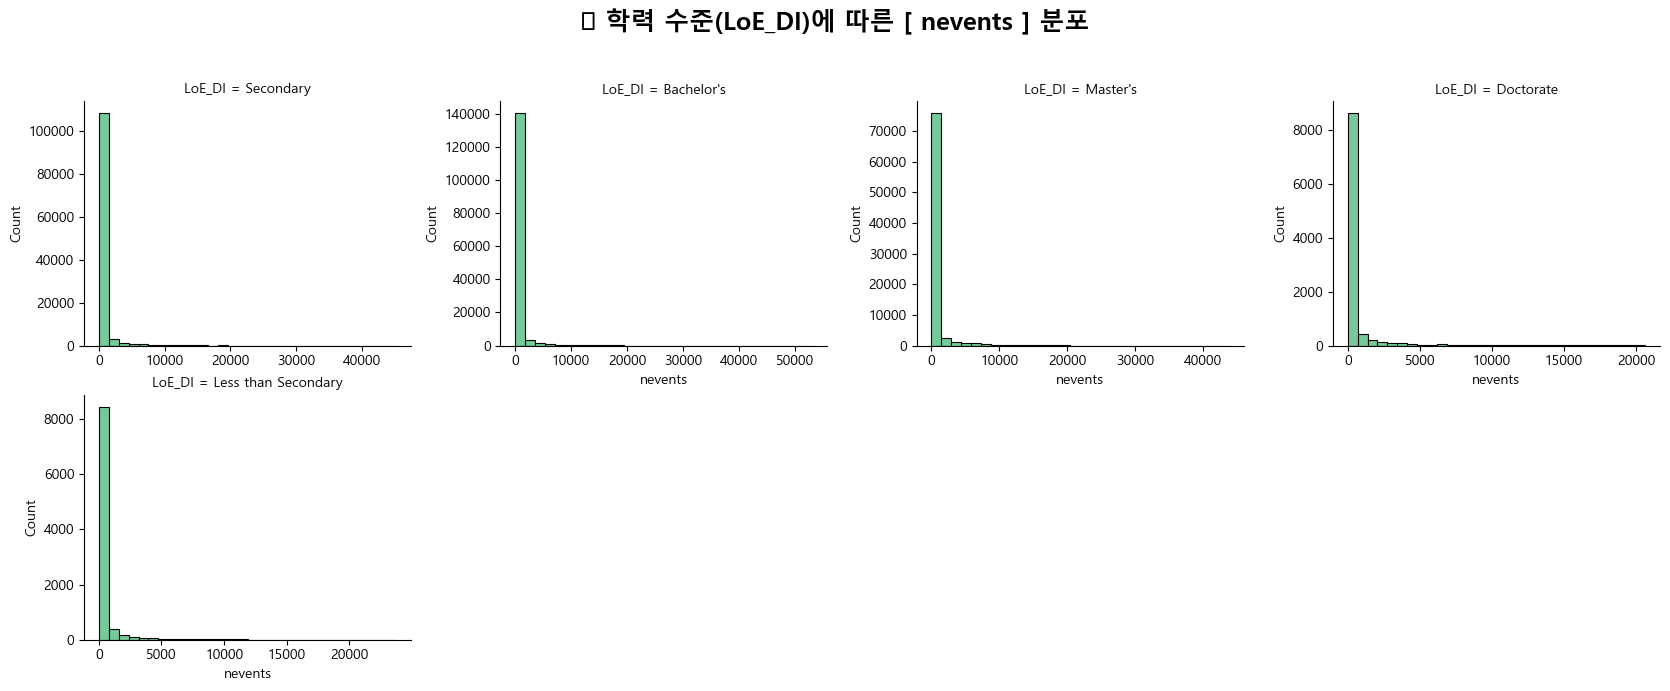

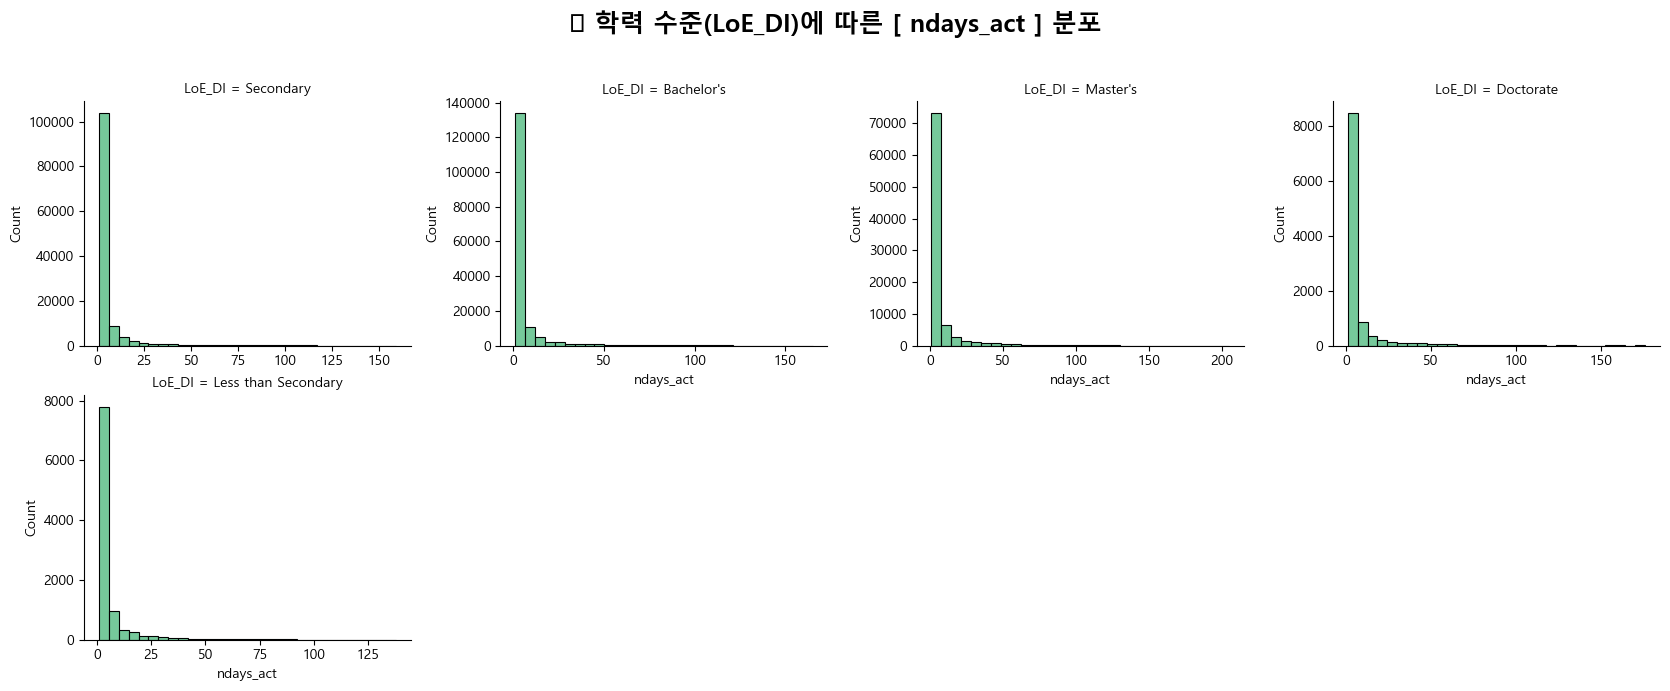

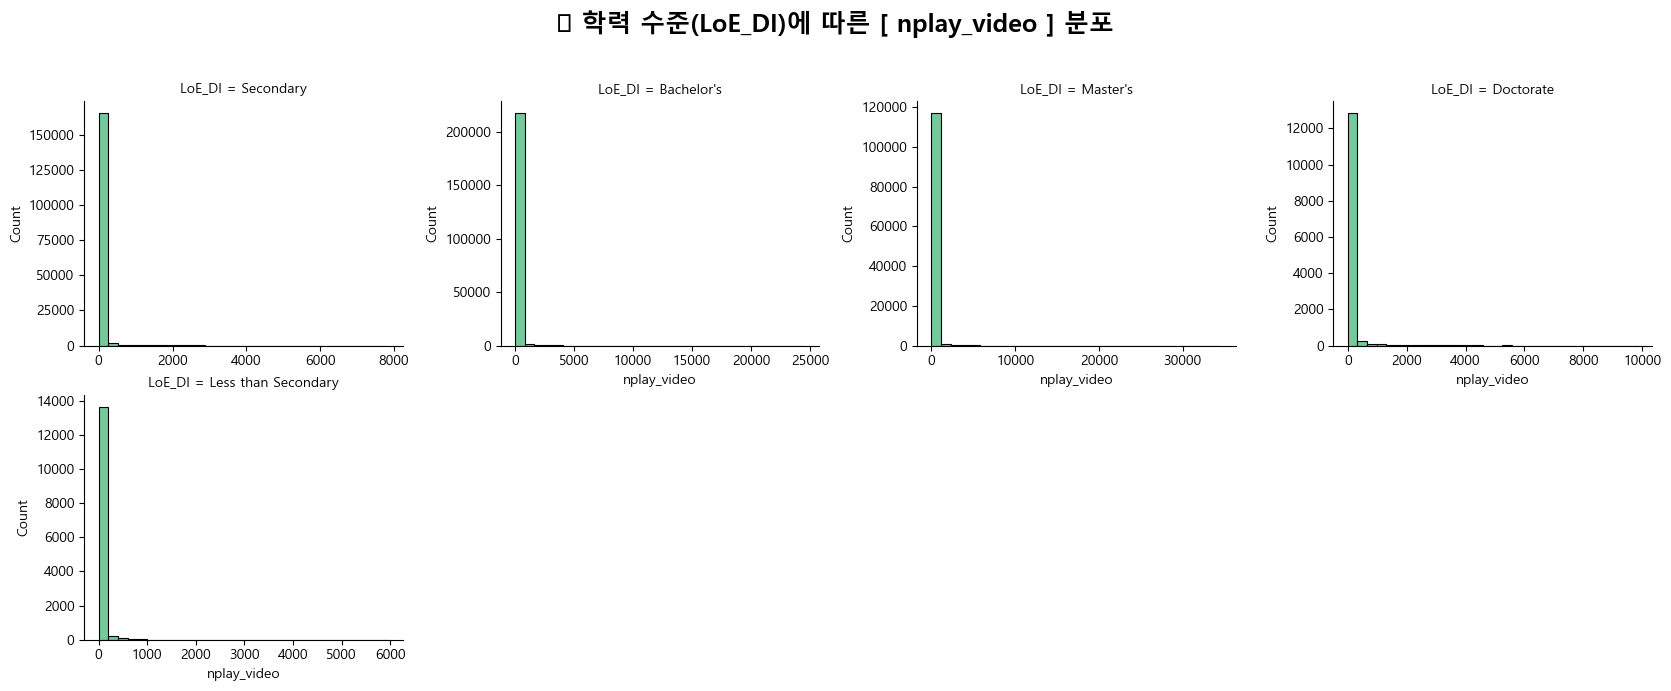

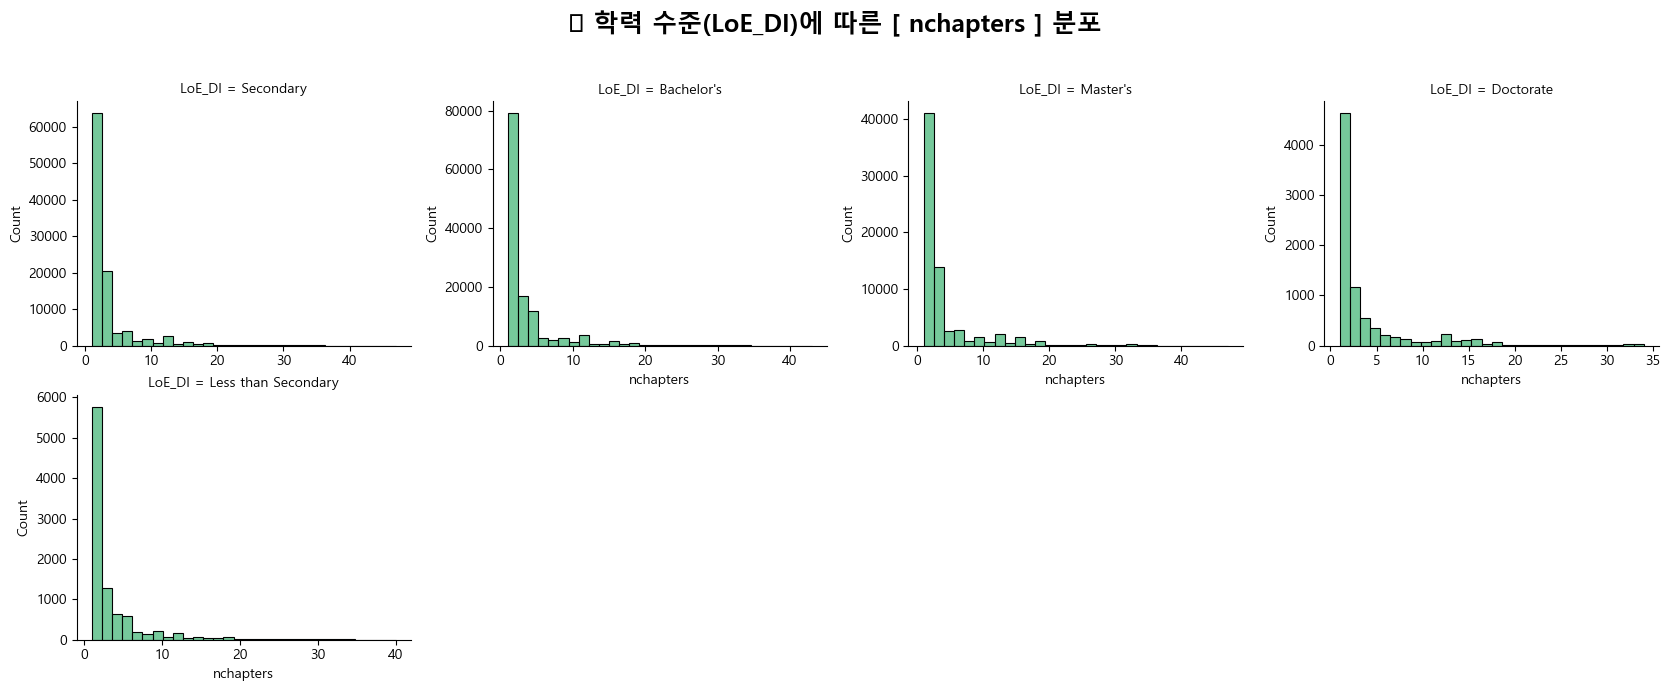

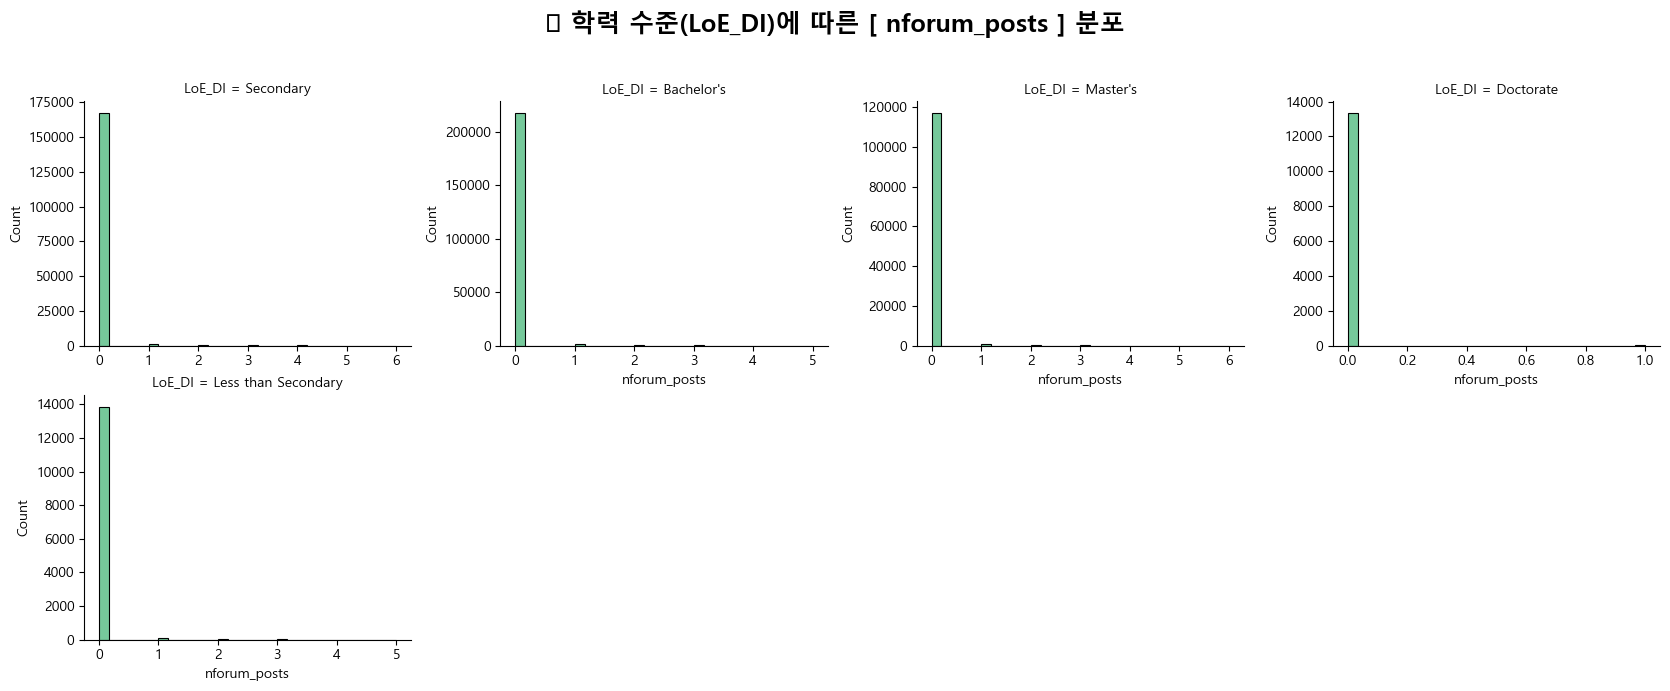

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트(윈도우) 및 마이너스 깨짐 방지 설정
plt.style.use('default')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 수치형 데이터 컬럼들만 추출
num_cols = df.select_dtypes(include=['number', 'float64', 'int64']).columns

# 수치형 컬럼 각각에 대해 학력 수준별 분포 그래프 생성
for col in num_cols:
    
    # 1. 시각화 틀(Grid) 만들기 
    # col='LoE_DI': 학력 종류마다 각각 다른 서브플롯을 만듦
    # col_wrap=4: 한 줄에 4개씩 그리고 다음 줄로 넘김
    # sharex, sharey=False: 각 그래프마다 값의 범위가 다르므로 축 스케일을 각각 독립적으로 맞춰줍니다.
    g = sns.FacetGrid(data=df, col='LoE_DI', col_wrap=4, height=3.5, aspect=1.2, sharex=False, sharey=False)
    
    # 2. 틀 안에 히스토그램(histplot) 그려 넣기
    g.map_dataframe(sns.histplot, x=col, bins=30, color='mediumseagreen', edgecolor='black', alpha=0.7)
    
    # 3. 레이아웃과 대제목 설정
    # suptitle이 그래프들과 겹치지 않도록 빈 공간(top=0.85) 확보
    g.fig.subplots_adjust(top=0.85)
    g.fig.suptitle(f'🎯 학력 수준(LoE_DI)에 따른 [ {col} ] 분포', fontsize=18, fontweight='bold')
    
    plt.show()


해당 집단(last_event_DI = Null) 데이터 수: 178,951명



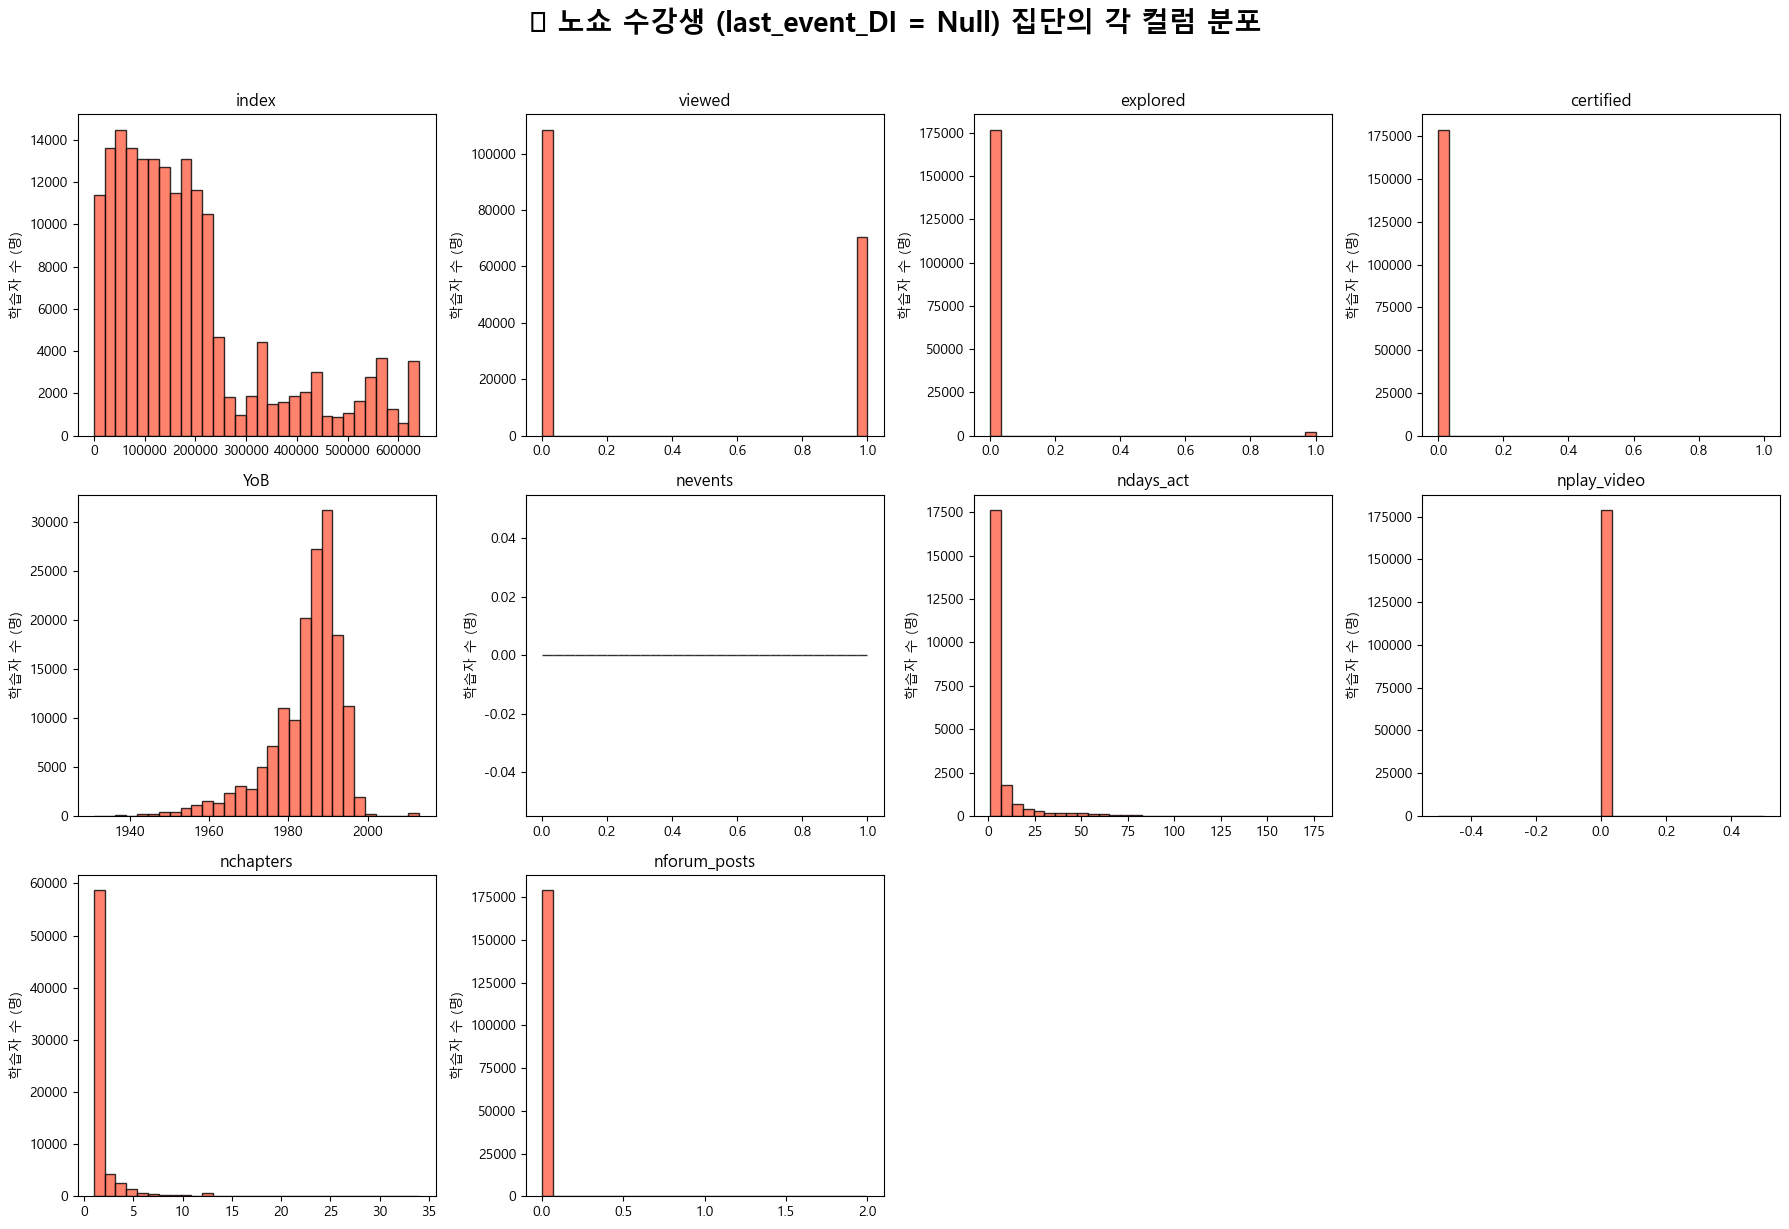

In [103]:
import matplotlib.pyplot as plt

# 1. last_event_DI가 Null인 '노쇼' 전용 데이터프레임 필터링
last_event_null = df[df['last_event_DI'].isnull()]

print(f"해당 집단(last_event_DI = Null) 데이터 수: {len(last_event_null):,}명\n")

# 2. 분포 비교 시각화 설정
plt.style.use('default')
plt.rcParams['font.family'] = 'Malgun Gothic'    # 윈도우 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지

# 수치형 컬럼들만 추출
num_cols = last_event_null.select_dtypes(include=['number']).columns

n_cols = 4 
n_rows = (len(num_cols) - 1) // n_cols + 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

# 각 컬럼별로 히스토그램 반복해서 그리기
for i, col in enumerate(num_cols):
    ax = axes[i]
    
    # 해당 집단은 붉은색 톤(tomato)으로 시각화
    ax.hist(last_event_null[col].dropna(), bins=30, color='tomato', edgecolor='black', alpha=0.8)
    
    ax.set_title(col, fontsize=12)
    ax.set_ylabel('학습자 수 (명)')

# 사용하지 않는 빈 서브플롯 틀은 숨기기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('👀 노쇼 수강생 (last_event_DI = Null) 집단의 각 컬럼 분포', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [104]:
last_event_null['certified'].sum()

np.int64(11)

In [105]:
last_event_null.describe()

,index,viewed,explored,certified,YoB,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts
count,178951.0000,178951.0000,178951.0000,178951.0000,157957.0000,178951,0,0.0000,21935.0000,178951.0000,69107.0000,178951.0000
mean,184666.2442,0.3935,0.0114,0.0001,1984.6528,2012-11-19 18:58:30.417935616,NaT,NaN,6.2629,0.0000,1.8090,0.0001
min,1.0000,0.0000,0.0000,0.0000,1931.0000,2012-07-23 00:00:00,NaT,NaN,1.0000,0.0000,1.0000,0.0000
25%,72382.5000,0.0000,0.0000,0.0000,1981.0000,2012-09-06 00:00:00,NaT,NaN,1.0000,0.0000,1.0000,0.0000
50%,145014.0000,0.0000,0.0000,0.0000,1987.0000,2012-10-20 00:00:00,NaT,NaN,2.0000,0.0000,1.0000,0.0000
75%,225246.0000,1.0000,0.0000,0.0000,1991.0000,2013-01-15 00:00:00,NaT,NaN,5.0000,0.0000,2.0000,0.0000
max,641137.0000,1.0000,1.0000,1.0000,2013.0000,2013-09-08 00:00:00,NaT,NaN,176.0000,0.0000,34.0000,2.0000
std,155126.9888,0.4885,0.1062,0.0078,8.9964,NaN,NaN,NaN,12.3000,0.0000,1.6536,0.0106


🔒 찐 노쇼(True No-show) 데이터 수: 108,530명



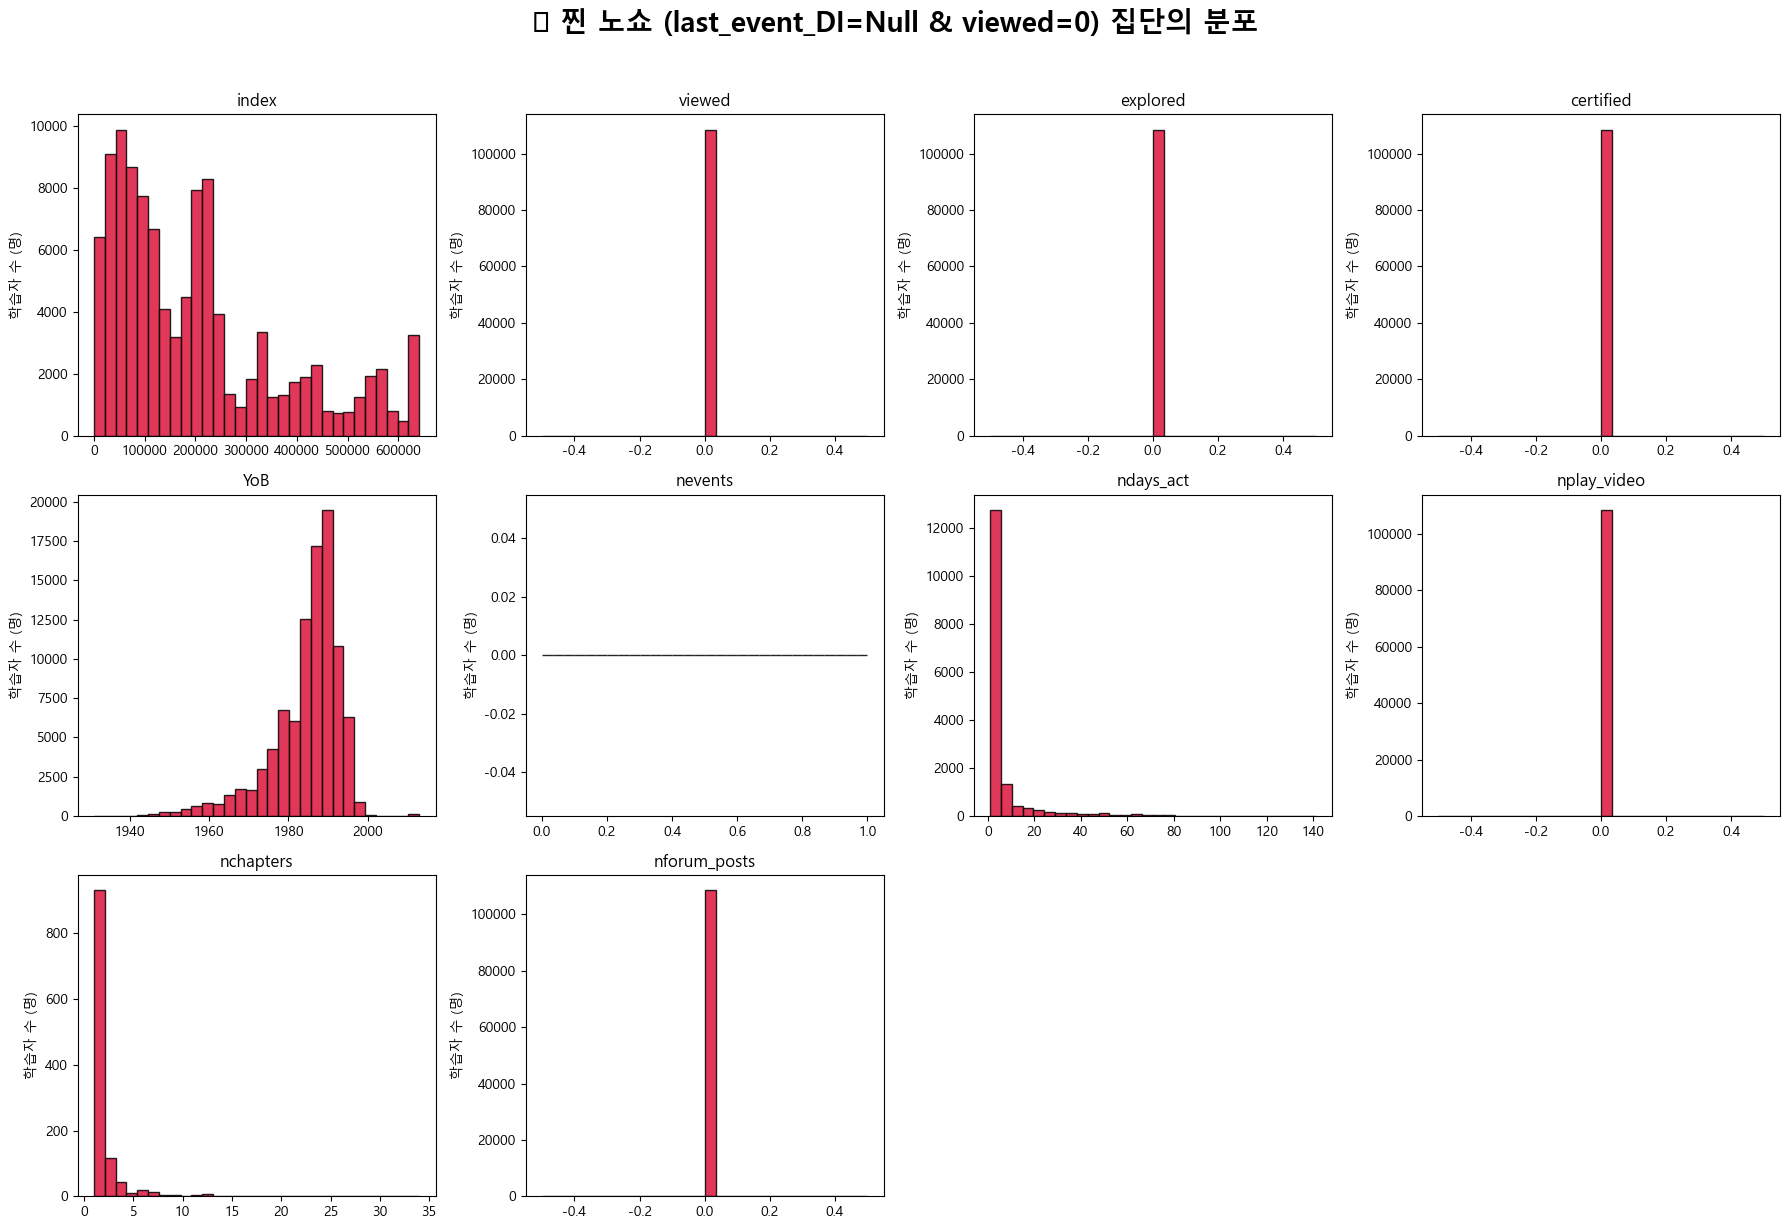

In [106]:
import matplotlib.pyplot as plt

# 1. '찐 노쇼' 그룹 정의 및 추출
# 조건 1: 마지막 이벤트 기록이 없음 (Null)
# 조건 2: 조회(viewed)조차 하지 않음 (0)
true_noshow = df[df['last_event_DI'].isnull() & (df['viewed'] == 0)]

print(f"🔒 찐 노쇼(True No-show) 데이터 수: {len(true_noshow):,}명\n")

# 2. 분포 비교 시각화 설정
plt.style.use('default')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 수치형 컬럼들만 추출
num_cols = true_noshow.select_dtypes(include=['number', 'float64', 'int64']).columns

n_cols = 4 
n_rows = (len(num_cols) - 1) // n_cols + 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

# 각 컬럼별로 찐 노쇼 집단(진홍색) 히스토그램 그리기
for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(true_noshow[col].dropna(), bins=30, color='crimson', edgecolor='black', alpha=0.85)
    
    ax.set_title(col, fontsize=12)
    ax.set_ylabel('학습자 수 (명)')

# 사용하지 않는 빈 서브플롯 틀은 숨기기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('🔒 찐 노쇼 (last_event_DI=Null & viewed=0) 집단의 분포', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
